In [ ]:
import gc
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import dataset
import utils
from model import BeautyScoreModel, score_persons


SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.cuda.set_device(0)


CONF = utils.load_conf("conf.yaml")[0]
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
CONF

2025-10-08 16:29:05.892660: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


{'C': 3,
 'H': 224,
 'W': 224,
 'F_H': 224,
 'F_W': 224,
 'N_MAX': 9,
 'N_CLASSES': 9,
 'DATASET_FILE': 'datasets/beauty_dataset.csv',
 'BATCH_SIZE': 32,
 'LR': 0.0001,
 'EPOCHS': 10,
 'MODEL': 'models/model_v8_classes_big_finetuned_state_dict.pt',
 'PATIENCE': 2}

In [2]:
def load_dataset(dataset):
    df = pd.read_csv(dataset, usecols=["folder_name", "score"])
    df = (
        df[~df["score"].isna()]
        .drop_duplicates()
        .reset_index(drop=True)
        .convert_dtypes()
    )
    return df


df = load_dataset(CONF["DATASET_FILE"])

<Axes: ylabel='score'>

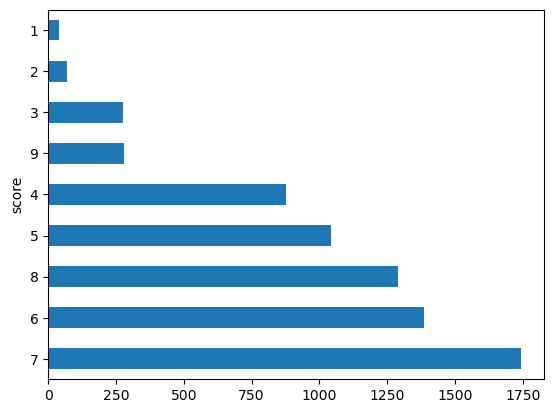

In [3]:
t = df["score"].value_counts()
t.plot(kind="barh")

In [4]:
utils.compute_class_weights(df), df["score"].value_counts().sort_index()

(tensor([5.0000, 5.0000, 2.8180, 0.8879, 0.7450, 0.5620, 0.4467, 0.6034, 2.7778]),
 score
 1      41
 2      69
 3     276
 4     876
 5    1044
 6    1384
 7    1741
 8    1289
 9     280
 Name: count, dtype: Int64)

In [5]:
raw_dataset = utils.load_raw_dataset(
    df, "/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset"
)
unique_scores = set([row["score"] for row in raw_dataset])
MAX_SCORE = max(unique_scores)
MIN_SCORE = min(unique_scores)
assert MAX_SCORE - MIN_SCORE == CONF["N_CLASSES"] - 1
raw_dataset[0]

{'id': 'person_1',
 'score': 7,
 'photos': ['/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_0.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_1.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_2.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_3.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_4.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_5.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_6.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_7.jpg',
  '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_8.jpg']}

In [6]:
raw_ds = dataset.BeautyDataset(raw_dataset)
for x in raw_ds:
    print(x)
    break

{'id': 'person_1', 'score': 7, 'photos': ['/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_0.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_1.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_2.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_3.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_4.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_5.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_6.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_7.jpg', '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset/person_1/photo_8.jpg']}


In [7]:
BATCH_SIZE = CONF["BATCH_SIZE"]
raw_dl = DataLoader(
    raw_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    collate_fn=raw_ds.collate_fn,
)
for x in raw_dl:
    # print(x)
    for a, b in zip(x.keys(), x.values()):
        print(f"{a} -> {b.shape}")
    break

ids -> (32,)
photos_tensor -> torch.Size([32, 9, 3, 224, 224])
photos_mask -> torch.Size([32, 9])
faces_tensor -> torch.Size([32, 9, 3, 224, 224])
faces_mask -> torch.Size([32, 9])
scores -> torch.Size([32])


In [9]:
lr = CONF["LR"]
EPOCHS = CONF["EPOCHS"]

model = BeautyScoreModel(conf = CONF)
model_params = list(filter(lambda p: p.requires_grad, model.parameters()))

class_weights = utils.compute_class_weights(df)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)
optimizer = optim.AdamW(model_params, lr=lr, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

finetune = CONF["MODEL"]
if finetune != "":
    try:
        model.load_state_dict(torch.load(finetune, weights_only=True))
    except Exception as e:
        print(f"Impossible to load model due to {e}. Training from scratch")

In [10]:
# Assert that changing the order of the images does not change the result
def randomize(t1, t2):
    idx = torch.randperm(t1.shape[1])
    t1 = t1[:, idx].view(t1.size())
    t2 = t2[:, idx].view(t2.size())
    return t1, t2


a, b = randomize(x["photos_tensor"], x["photos_mask"])
c, d = randomize(x["faces_tensor"], x["faces_mask"])
model.eval()
res1 = model(x["photos_tensor"], x["photos_mask"], x["faces_tensor"], x["faces_mask"])
res2 = model(a, b, c, d)
model.train()
(res1 - res2).abs().max()

tensor(9.5367e-07, grad_fn=<MaxBackward1>)

In [ ]:
N_CLASSES = CONF["N_CLASSES"]
STEPS = len(raw_ds) // BATCH_SIZE
CLASS_DELTA = MAX_SCORE - N_CLASSES
PATIENCE = CONF["PATIENCE"]


def train(model, dl_train):
    best_loss = 100
    for epoch in tqdm(range(EPOCHS), position=0):
        model.train()
        train_loss = 0
        with tqdm(dl_train, total=STEPS, position=1) as pbar:
            for step, batch in enumerate(pbar):
                photos_tensor = batch["photos_tensor"].to(device)
                photos_mask = batch["photos_mask"].to(device)
                faces_tensor = batch["faces_tensor"].to(device)
                faces_mask = batch["faces_mask"].to(device)
                labels = batch["scores"].to(device) - MIN_SCORE  # 0-8

                optimizer.zero_grad()
                # with torch.amp.autocast(
                #     device_type=torch.device
                # ):
                logits = model(photos_tensor, photos_mask, faces_tensor, faces_mask)
                loss = criterion(logits, labels.long())

                # scaler.scale(loss).backward()
                # scaler.step(optimizer)
                # scaler.update()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                pbar.set_description(
                    f"Epoch {epoch+1}/{EPOCHS} - Train - Loss: {round(train_loss / (step+1),4)}"
                )

            avg_train_loss = train_loss / STEPS
            score_persons(batch, model, 5)
            scheduler.step()  # Update LR

            # Early stopping
            if avg_train_loss < best_loss:
                best_loss = avg_train_loss
                torch.save(model.state_dict(), "models/model_state_dict.pth")
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= PATIENCE:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
    return model


gc.collect()
torch.cuda.empty_cache()
model.to(device)
model = train(model, raw_dl)
torch.save(model.state_dict(), "models/model_state_dict_final.pt")
torch.save(model, "models/model.pt")

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

KeyboardInterrupt: 

tensor(1.0729e-06, grad_fn=<MaxBackward1>)